<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/Content_Segmentation_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Content Segmentation - Unsupervised Learning


This notebook discovers natural groups of content using:

- **K-Means**
- **Hierarchical Clustering**
- **DBSCAN**

The objective is not to predict a target. Instead, we want to discover **content segments** that have similar traffic, engagement, ranking, search-demand, competition, and content characteristics.

Potential segments include:

- High traffic / declining
- High traffic / growing
- Low traffic / declining
- Low traffic / stable
- High engagement / low ranking
- Low engagement / high impressions

The notebook uses the CSV dataset only and does **not** use DuckDB.


In [3]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Business Question

Instead of asking:

> **Can we predict whether content will decline?**

we ask:

> **What natural groups of content exist in the dataset?**

This can help FlyRank identify different content strategies rather than applying one strategy to every article.


In [4]:
# Install / import required packages
!pip -q install scikit-learn scipy seaborn matplotlib pandas numpy joblib

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs_content_segmentation")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")


Libraries loaded.


In [5]:
# 2. Load the FlyRank CSV dataset

CSV_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [6]:
# 3. Inspect available columns

print("Columns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Columns:
- content_id
- client_id
- search_volume
- competition
- competition_level
- cpc
- content_type
- main_intent
- word_count
- char_count
- provider_used
- model_used
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- users_90d
- engaged_sessions_90d
- ai_sessions_90d
- scroll_events_90d
- days_with_impressions
- days_with_sessions
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- content_age_days
- age_tier
- age_tier_order
- days_since_last_update
- freshness_tier
- word_count_tier
- char_count_tier
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct
- impression_tier
- position_tier
- trend_direction
- trend_pct

Data types:


,dtype
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64


## 4. Segmentation Feature Design

For clustering, we should use variables that describe the **state of the content**.

The initial feature set follows the features already used in the FlyRank modeling work:

### Traffic / engagement
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`

### Search / ranking
- `search_volume`
- `avg_position`

### Competition
- `competition`
- `cpc`

### Content characteristics
- `word_count`
- `char_count`
- `content_age_days`
- `days_since_last_update`

We intentionally do **not** use `trend_direction` or `is_declining_label` to create clusters. Those variables are useful later for **interpreting** the discovered clusters.

This is important: the clustering algorithm should discover the segments rather than being explicitly told which articles are declining.


In [7]:
# 5. Select segmentation features

SEGMENTATION_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
]

missing_features = [
    feature for feature in SEGMENTATION_FEATURES
    if feature not in df.columns
]

if missing_features:
    raise ValueError(f"Missing required features: {missing_features}")

X_raw = df[SEGMENTATION_FEATURES].copy()

print("Segmentation features:")
display(X_raw.head())


Segmentation features:


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position
0,10.0,0.67,2.05,3221.0,20457.0,987,13,9,187,20,10.6
1,90.0,0.01,0.05,2481.0,15562.0,5915,1,2,445,25,20.3
2,0.0,0.00,0.00,3515.0,23643.0,6089,3,3,141,20,36.5
3,10.0,0.00,0.00,NaN,NaN,4206,17,26,463,22,6.2
4,0.0,0.00,0.00,2803.0,17469.0,6452,2,9,263,14,44.0


In [8]:
# 6. Basic data-quality inspection

quality = pd.DataFrame({
    "dtype": X_raw.dtypes.astype(str),
    "missing_count": X_raw.isna().sum(),
    "missing_pct": X_raw.isna().mean() * 100,
    "unique_values": X_raw.nunique(),
})

display(quality)

print("\nSummary statistics:")
display(X_raw.describe().T)


,dtype,missing_count,missing_pct,unique_values
search_volume,float64,2468,8.226667,41
competition,float64,2468,8.226667,101
cpc,float64,2468,8.226667,915
word_count,float64,7699,25.663333,5476
char_count,float64,7699,25.663333,14839
impressions_prev_30d,int64,0,0.000000,5931
clicks_prev_30d,int64,0,0.000000,258
sessions_prev_30d,int64,0,0.000000,311
content_age_days,int64,0,0.000000,225
days_since_last_update,int64,0,0.000000,57



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.0,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.0,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.0,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.0,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.0,24011.00,111158.00
impressions_prev_30d,30000.0,1783.078500,6150.429511,0.0,19.0,210.0,1143.00,218786.00
clicks_prev_30d,30000.0,5.435100,28.358673,0.0,0.0,0.0,2.00,1627.00
sessions_prev_30d,30000.0,10.283000,42.578003,0.0,1.0,2.0,7.00,4247.00
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.0,333.00,564.00
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.0,104.00,373.00


## 7. Preprocessing for Clustering

Distance-based algorithms are sensitive to scale.

For example:

- `search_volume` may be thousands
- `avg_position` may be between roughly 1 and several dozen
- `cpc` may be much smaller

Without scaling, large-magnitude variables can dominate the distance calculation.

We therefore use:

1. **Median imputation**
2. **StandardScaler**

The scaler is fitted only on the dataset being clustered.


In [9]:
# 8. Impute missing values and standardize features

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=SEGMENTATION_FEATURES,
    index=df.index
)

print("Scaled matrix shape:", X_scaled.shape)
display(X_scaled.head())


Scaled matrix shape: (30000, 11)


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position
0,-0.093905,1.937363,0.795280,0.137282,0.021643,-0.129437,0.266762,-0.030133,-0.521212,-0.620236,-0.377378
1,-0.038923,-0.452052,-0.195979,-0.451774,-0.537956,0.671821,-0.156396,-0.194540,1.422939,-0.501409,0.260087
2,-0.100778,-0.488255,-0.220761,0.371313,0.385868,0.700113,-0.085869,-0.171054,-0.867844,-0.620236,1.324718
3,-0.093905,-0.488255,-0.220761,-0.136549,-0.131661,0.393950,0.407815,0.369140,1.558578,-0.572705,-0.666537
4,-0.100778,-0.488255,-0.220761,-0.195455,-0.319947,0.759134,-0.121133,-0.030133,0.051484,-0.762828,1.817603


# 9. Exploratory Distributions

Before clustering, inspect the distributions of the segmentation variables.

Highly skewed traffic variables can create very large distances. We will first visualize the raw distributions and then evaluate whether a log transformation is useful.


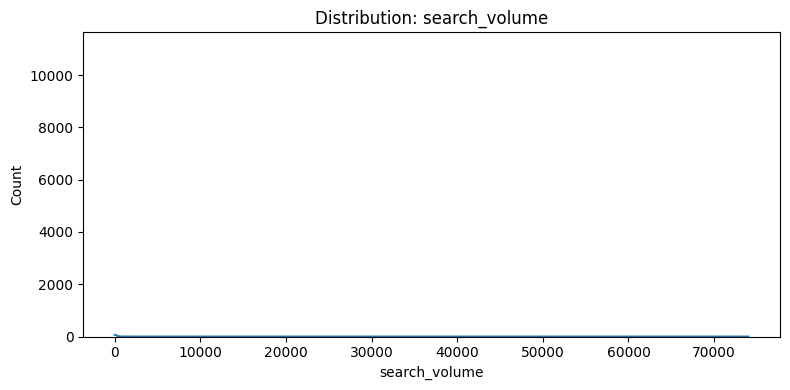

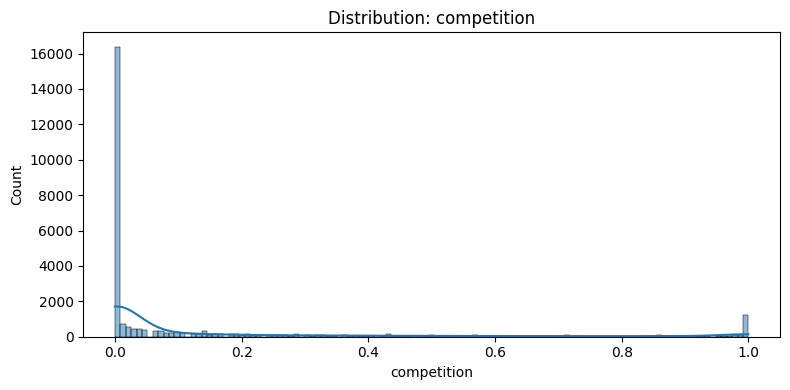

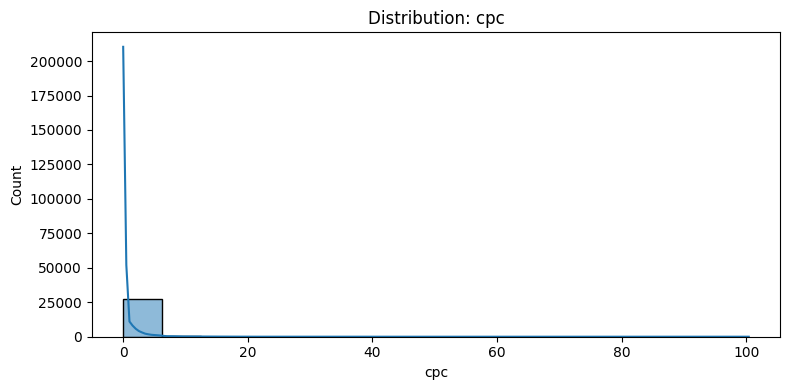

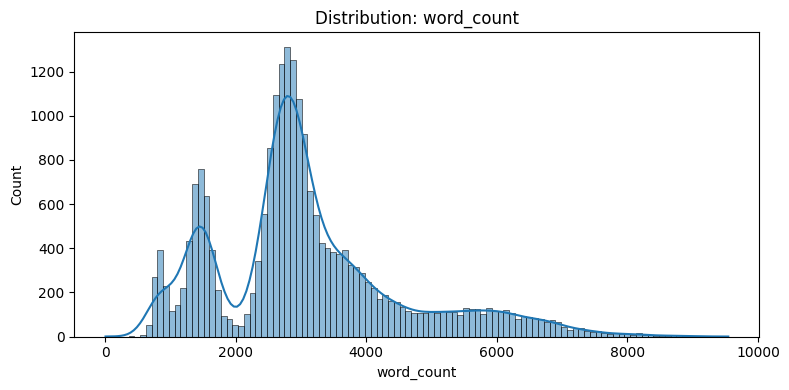

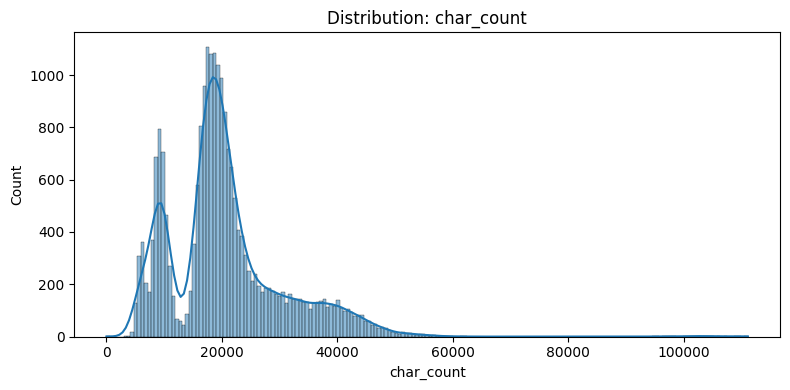

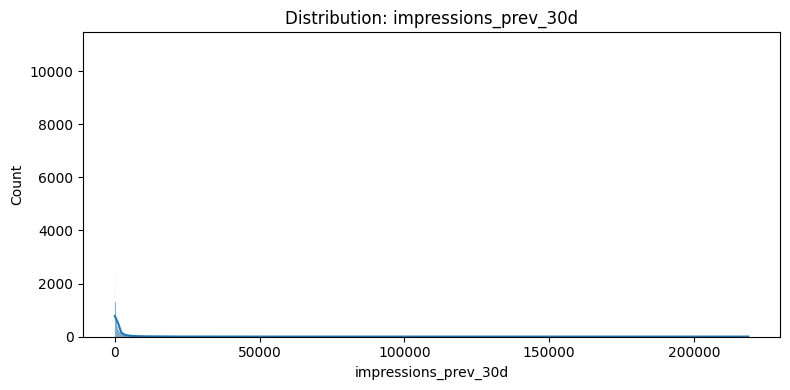

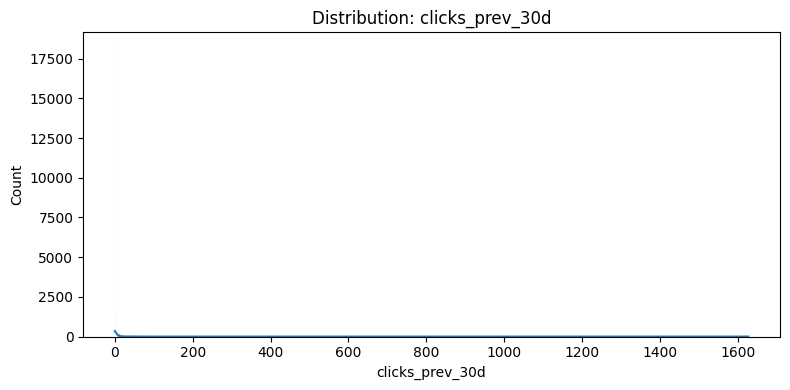

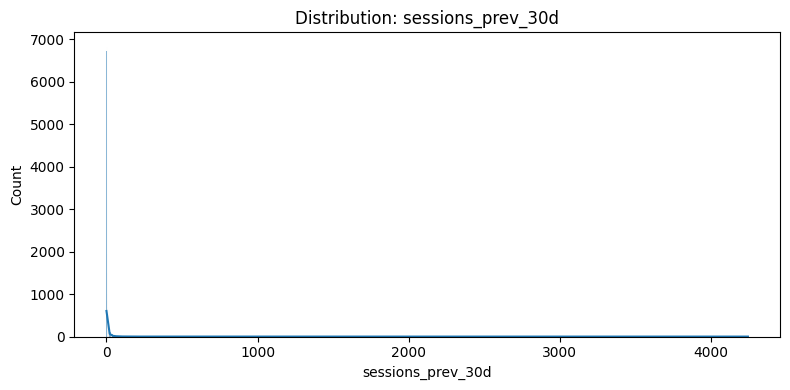

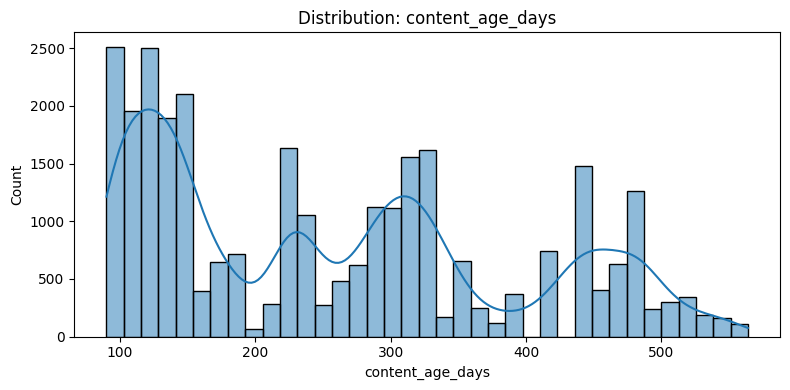

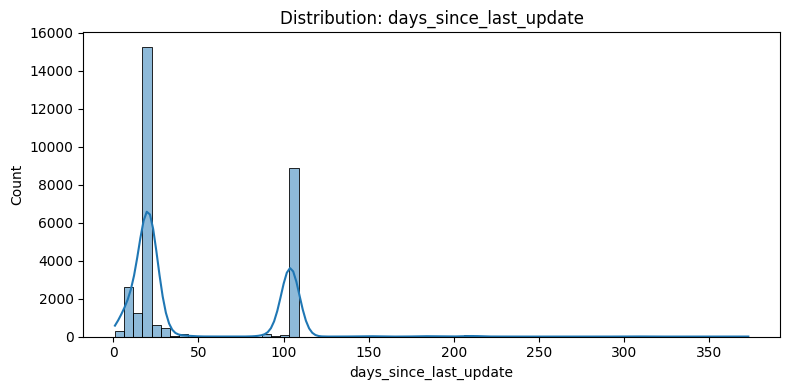

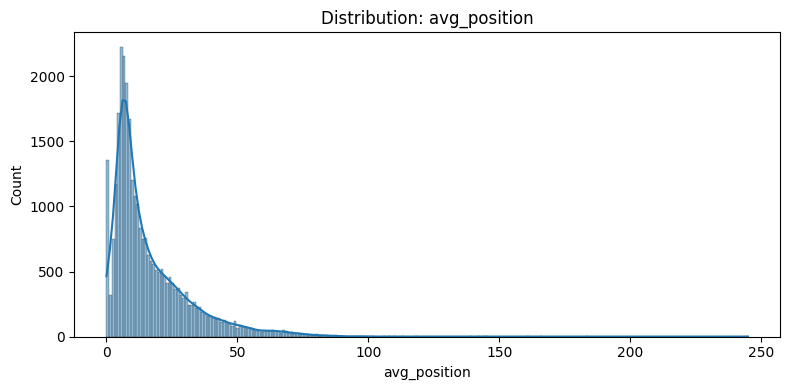

In [10]:
# 9.1 Raw feature distributions

for feature in SEGMENTATION_FEATURES:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature].dropna(), kde=True)
    plt.title(f"Distribution: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 10. Optional Log Transformation

Traffic variables often have heavy right tails. A very high-traffic article can otherwise dominate Euclidean distance.

We use `log1p` for non-negative variables where appropriate:

- search volume
- CPC
- word/character counts
- impressions
- clicks
- sessions
- content age
- days since update

`competition` and `avg_position` are left on their original scale before standardization.

This transformation is designed to make clustering reflect **relative differences** more reasonably for highly skewed variables.


In [11]:
# 10. Apply log1p to selected non-negative, skewed variables

LOG_FEATURES = [
    "search_volume",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
]

X_cluster_raw = X_raw.copy()

for feature in LOG_FEATURES:
    X_cluster_raw[feature] = np.log1p(
        X_cluster_raw[feature].clip(lower=0)
    )

X_cluster_imputed = imputer.fit_transform(X_cluster_raw)
X_cluster_scaled = scaler.fit_transform(X_cluster_imputed)

X_cluster_scaled = pd.DataFrame(
    X_cluster_scaled,
    columns=SEGMENTATION_FEATURES,
    index=df.index
)

print("Clustering matrix:", X_cluster_scaled.shape)


Clustering matrix: (30000, 11)


# 11. K-Means — Choosing the Number of Clusters

K-Means requires us to choose `k`.

We will compare:

- **Inertia / elbow**
- **Silhouette score**
- **Davies-Bouldin index**
- **Calinski-Harabasz score**

No single metric should automatically decide the answer. We want a solution that is mathematically reasonable **and** produces useful, interpretable content segments.


In [12]:
# 11. Evaluate candidate K values

k_values = range(2, 11)
k_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(X_cluster_scaled)

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_cluster_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster_scaled, labels),
    })

k_results = pd.DataFrame(k_results)
display(k_results)


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,268587.357558,0.181594,1.827568,6859.075711
1,3,230217.093089,0.202733,1.698521,6500.799041
2,4,200357.359457,0.212337,1.543223,6469.710903
3,5,180148.643218,0.206384,1.574536,6237.618202
4,6,164472.937372,0.221045,1.485490,6037.252731
5,7,154172.891889,0.220570,1.436662,5700.942423
6,8,146456.148971,0.220774,1.375781,5369.579017
7,9,139390.524424,0.223890,1.488174,5126.401187
8,10,132811.196647,0.201234,1.516789,4947.452352


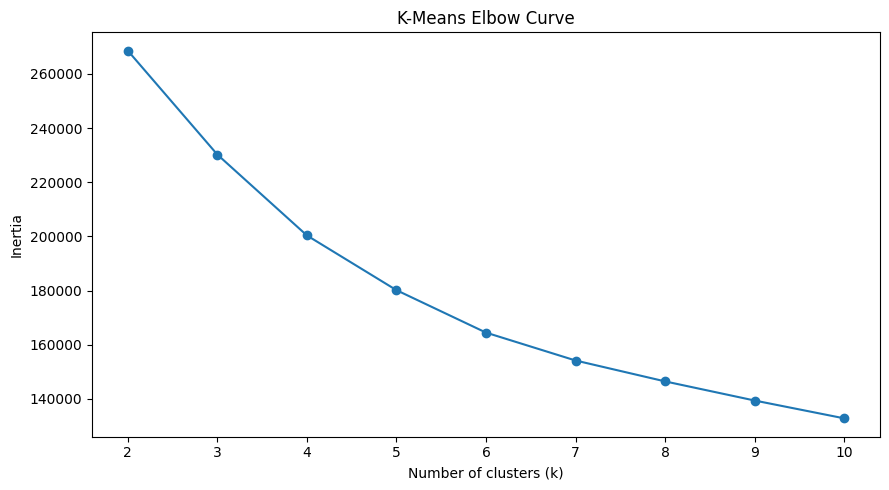

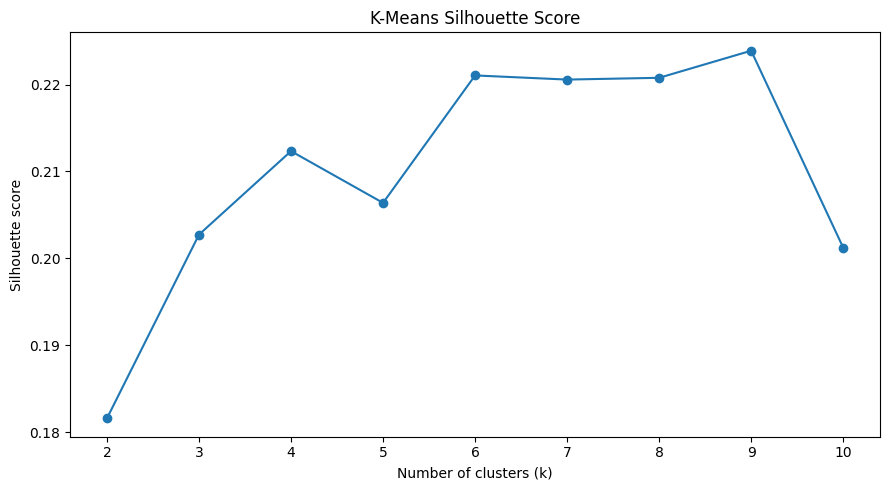

In [13]:
# Plot K-Means diagnostics

plt.figure(figsize=(9, 5))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 12. Select K

The next cell selects the best silhouette score as a **starting point**.

This is not a claim that the mathematically highest silhouette is automatically the best business segmentation. We will inspect the resulting cluster profiles before accepting it.


In [14]:
best_k = int(
    k_results.loc[k_results["silhouette"].idxmax(), "k"]
)

print("Initial recommended k from silhouette:", best_k)


Initial recommended k from silhouette: 9


In [15]:
# 13. Fit the final initial K-Means model

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

df_seg = df.copy()
df_seg["kmeans_cluster"] = kmeans_labels

print(df_seg["kmeans_cluster"].value_counts().sort_index())


kmeans_cluster
0    2603
1    1896
2    3726
3    7289
4    3048
5    4223
6    2248
7    3454
8    1513
Name: count, dtype: int64


# 14. Hierarchical Clustering

Hierarchical clustering provides a different view of the same segmentation problem.

Instead of directly assigning points to `k` groups, it builds a hierarchy of similar observations.

We first inspect a sample dendrogram because plotting every article can become unreadable on a large dataset.


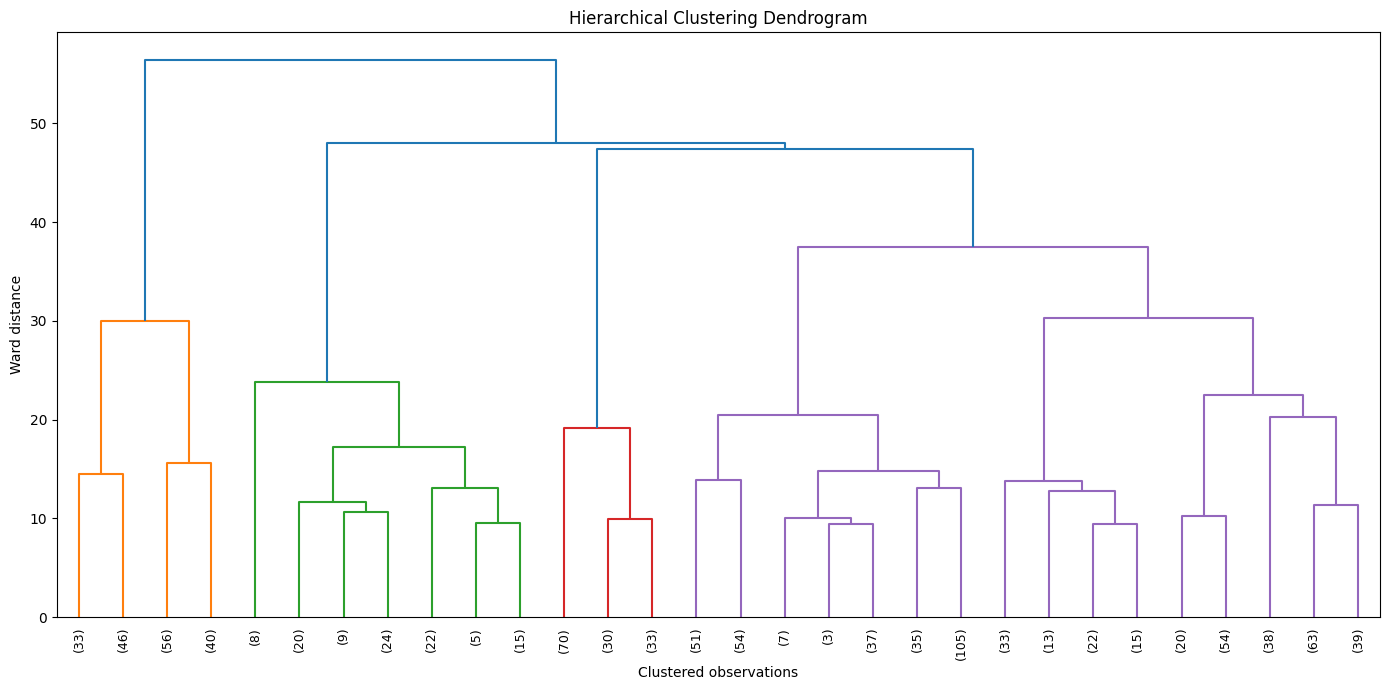

In [16]:
# 14. Hierarchical clustering dendrogram on a sample

DENDROGRAM_SAMPLE_SIZE = min(1000, len(X_cluster_scaled))

sample_indices = (
    df_seg.sample(
        DENDROGRAM_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).index
)

X_hier_sample = X_cluster_scaled.loc[sample_indices]

Z = linkage(
    X_hier_sample,
    method="ward",
    metric="euclidean"
)

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered observations")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


In [17]:
# 15. Fit Agglomerative Clustering using the same initial k

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_cluster_scaled)

df_seg["hierarchical_cluster"] = hierarchical_labels

print(
    df_seg["hierarchical_cluster"]
    .value_counts()
    .sort_index()
)


hierarchical_cluster
0    7498
1    3114
2    3608
3    3424
4    3367
5    5161
6    1657
7    1204
8     967
Name: count, dtype: int64


# 16. DBSCAN

DBSCAN is useful because it does **not** require us to specify the number of clusters in advance.

It can also identify:

- dense groups
- irregularly shaped groups
- outliers/noise

The important hyperparameters are:

- `eps`
- `min_samples`

We will inspect a k-nearest-neighbor distance curve to help choose an initial `eps`.


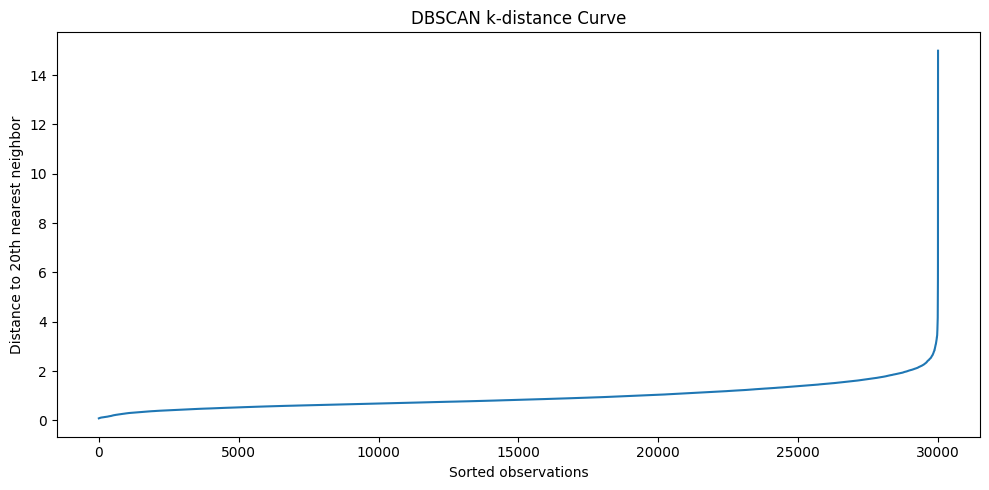

Initial min_samples: 20
Use the curve's elbow to choose an initial eps.


In [18]:
# 17. K-nearest-neighbor distance curve for DBSCAN

MIN_SAMPLES = max(5, min(20, int(np.sqrt(len(X_cluster_scaled)))))

neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES
)

neighbors.fit(X_cluster_scaled)

distances, _ = neighbors.kneighbors(X_cluster_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
plt.title("DBSCAN k-distance Curve")
plt.tight_layout()
plt.show()

print("Initial min_samples:", MIN_SAMPLES)
print("Use the curve's elbow to choose an initial eps.")


In [19]:
# 18. DBSCAN parameter search

# Instead of hard-coding one eps value, evaluate several candidates.
# The best candidate is then selected using silhouette only when DBSCAN
# produces at least two non-noise clusters.

eps_candidates = np.linspace(
    np.percentile(k_distances, 70),
    np.percentile(k_distances, 98),
    10
)

dbscan_results = []

for eps in eps_candidates:
    model = DBSCAN(
        eps=float(eps),
        min_samples=MIN_SAMPLES
    )

    labels = model.fit_predict(X_cluster_scaled)

    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise]))
    noise_pct = (~non_noise).mean() * 100

    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(
            X_cluster_scaled.loc[non_noise],
            labels[non_noise]
        )
    else:
        sil = np.nan

    dbscan_results.append({
        "eps": float(eps),
        "clusters": n_clusters,
        "noise_pct": noise_pct,
        "silhouette_non_noise": sil
    })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results)


,eps,clusters,noise_pct,silhouette_non_noise
0,1.095645,8,18.363333,0.011765
1,1.219297,5,13.050000,0.010171
2,1.342950,2,8.753333,0.138464
3,1.466602,2,5.880000,0.132692
4,1.590255,3,3.813333,0.092899
5,1.713907,2,2.493333,0.124579
6,1.837560,2,1.483333,0.290697
7,1.961212,1,1.000000,NaN
8,2.084865,1,0.566667,NaN
9,2.208517,1,0.376667,NaN


In [20]:
# 19. Fit initial DBSCAN model

valid_dbscan = dbscan_results.dropna(subset=["silhouette_non_noise"])

if len(valid_dbscan) > 0:
    best_eps = float(
        valid_dbscan.loc[
            valid_dbscan["silhouette_non_noise"].idxmax(),
            "eps"
        ]
    )
else:
    best_eps = float(np.median(eps_candidates))

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=MIN_SAMPLES
)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

df_seg["dbscan_cluster"] = dbscan_labels

print("Selected eps:", best_eps)
print("\nDBSCAN cluster counts:")
print(df_seg["dbscan_cluster"].value_counts().sort_index())


Selected eps: 1.8375599585069038

DBSCAN cluster counts:
dbscan_cluster
-1      445
 0    29541
 1       14
Name: count, dtype: int64


# 20. Dimensionality Reduction for Visualization

The clustering algorithms operate in the full feature space.

For visualization, we use PCA to project the standardized feature matrix into two dimensions.

Important:

> PCA visualization is only a 2D representation. It does not mean the original clustering problem is actually two-dimensional.


In [21]:
# 21. PCA 2D visualization

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X_cluster_scaled)

df_seg["PCA_1"] = X_pca[:, 0]
df_seg["PCA_2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.28633826 0.17833301]
Total explained variance: 0.46467127196552016


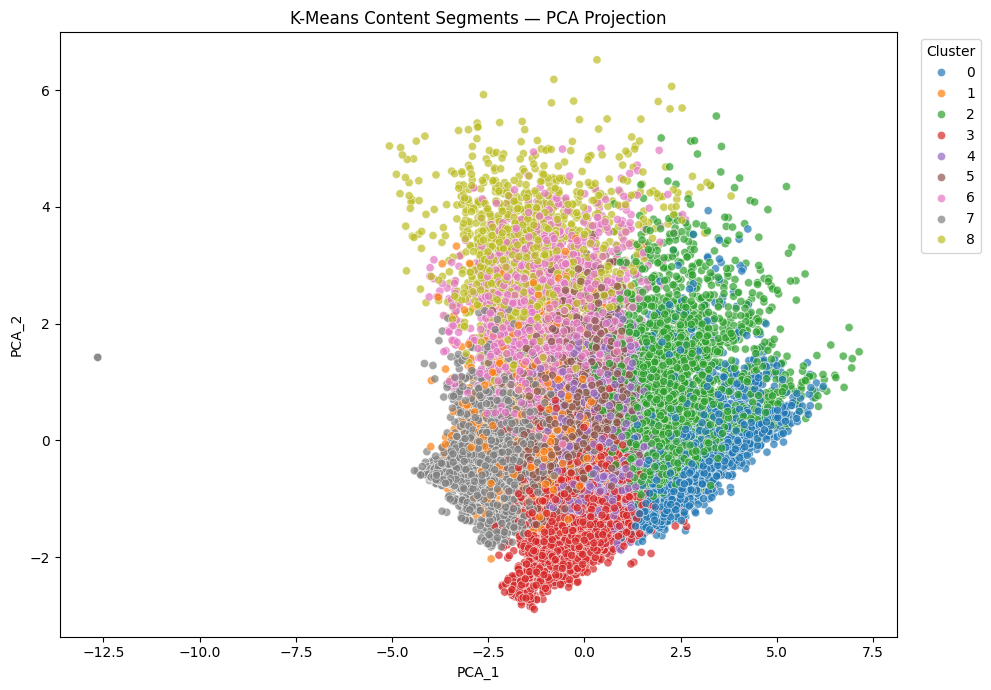

In [22]:
# K-Means PCA visualization

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_seg,
    x="PCA_1",
    y="PCA_2",
    hue="kmeans_cluster",
    palette="tab10",
    s=35,
    alpha=0.7
)
plt.title("K-Means Content Segments — PCA Projection")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


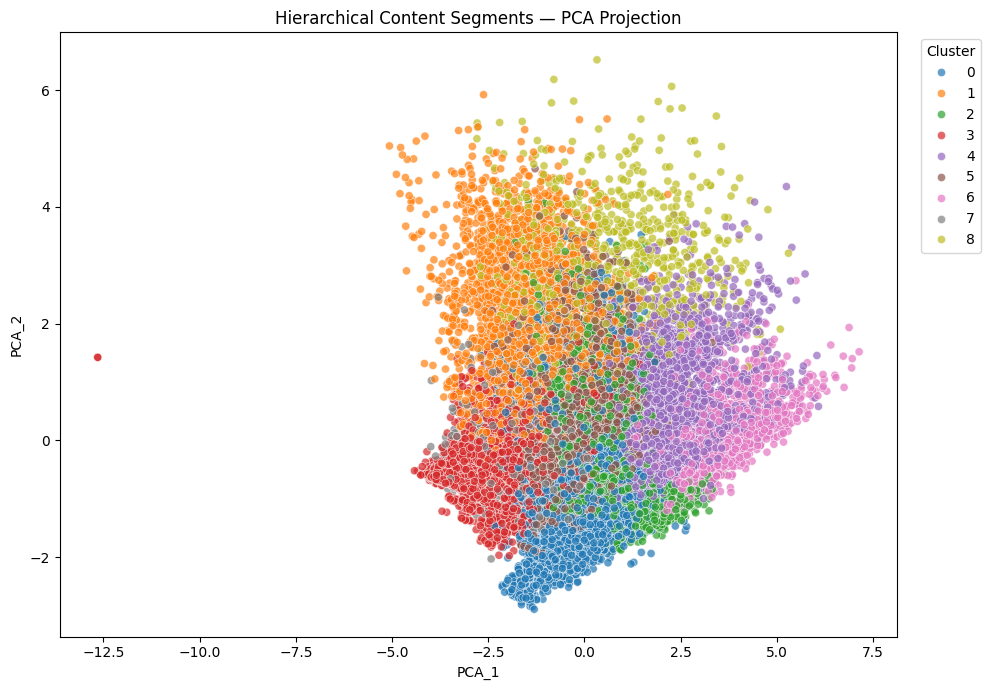

In [23]:
# Hierarchical clustering PCA visualization

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_seg,
    x="PCA_1",
    y="PCA_2",
    hue="hierarchical_cluster",
    palette="tab10",
    s=35,
    alpha=0.7
)
plt.title("Hierarchical Content Segments — PCA Projection")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


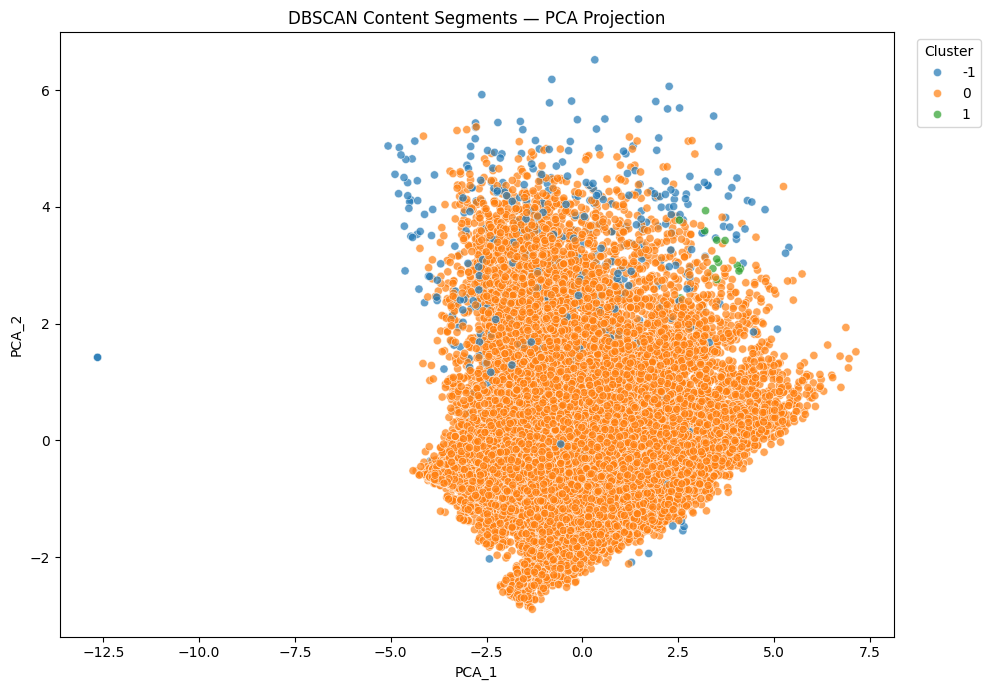

In [24]:
# DBSCAN PCA visualization

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_seg,
    x="PCA_1",
    y="PCA_2",
    hue="dbscan_cluster",
    palette="tab10",
    s=35,
    alpha=0.7
)
plt.title("DBSCAN Content Segments — PCA Projection")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# 22. Cluster Profiling

This is the most important part of the notebook.

A clustering algorithm only gives us labels such as:

```text
Cluster 0
Cluster 1
Cluster 2
...
```

Those labels have **no business meaning by themselves**.

We therefore calculate the mean/median feature profile of every cluster and compare it with the overall dataset.

This is where we turn mathematical clusters into **content segments**.


In [25]:
# 23. K-Means cluster profile

profile_features = SEGMENTATION_FEATURES

overall_median = df_seg[profile_features].median()

kmeans_profile = (
    df_seg
    .groupby("kmeans_cluster")[profile_features]
    .median()
)

kmeans_size = (
    df_seg["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("article_count")
)

kmeans_profile = kmeans_profile.join(kmeans_size)
kmeans_profile["share_pct"] = (
    kmeans_profile["article_count"] / len(df_seg) * 100
)

display(kmeans_profile)


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position,article_count,share_pct
kmeans_cluster,,,,,,,,,,,,,
0,0.0,0.00,0.00,5957.0,39117.0,1449.0,2.0,14.0,229.0,104.0,21.30,2603,8.676667
1,10.0,0.01,0.00,2666.5,17729.5,57.0,0.0,1.0,348.0,22.0,52.85,1896,6.320000
2,10.0,0.00,0.00,2938.0,19392.5,4614.5,15.0,23.0,153.0,20.0,6.50,3726,12.420000
3,0.0,0.00,0.00,3012.5,20520.5,56.0,0.0,1.0,126.0,20.0,8.90,7289,24.296667
4,10.0,0.00,0.00,3523.0,22151.0,305.0,0.0,2.0,257.0,104.0,8.90,3048,10.160000
5,10.0,0.00,0.00,2819.0,17839.0,321.0,0.0,3.0,445.0,22.0,12.30,4223,14.076667
6,20.0,0.97,0.89,2733.5,17396.0,124.0,0.0,1.0,187.0,20.0,12.30,2248,7.493333
7,10.0,0.00,0.00,1347.0,8760.0,3.0,0.0,1.0,295.0,20.0,6.70,3454,11.513333
8,40.0,0.49,4.23,2470.5,15849.5,146.0,0.0,1.0,310.0,22.0,16.30,1513,5.043333


In [26]:
# 24. K-Means profile as ratio to overall median

kmeans_ratio = (
    df_seg
    .groupby("kmeans_cluster")[profile_features]
    .median()
    .divide(overall_median)
)

display(kmeans_ratio.round(2))


,search_volume,competition,cpc,word_count,char_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,days_since_last_update,avg_position
kmeans_cluster,,,,,,,,,,,
0,0.0,NaN,NaN,2.07,2.05,6.90,inf,7.0,0.97,5.2,1.97
1,1.0,inf,NaN,0.93,0.93,0.27,NaN,0.5,1.47,1.1,4.89
2,1.0,NaN,NaN,1.02,1.01,21.97,inf,11.5,0.65,1.0,0.60
3,0.0,NaN,NaN,1.05,1.07,0.27,NaN,0.5,0.53,1.0,0.82
4,1.0,NaN,NaN,1.22,1.16,1.45,NaN,1.0,1.09,5.2,0.82
5,1.0,NaN,NaN,0.98,0.93,1.53,NaN,1.5,1.89,1.1,1.14
6,2.0,inf,inf,0.95,0.91,0.59,NaN,0.5,0.79,1.0,1.14
7,1.0,NaN,NaN,0.47,0.46,0.01,NaN,0.5,1.25,1.0,0.62
8,4.0,inf,inf,0.86,0.83,0.70,NaN,0.5,1.31,1.1,1.51


## 25. Heatmap of Cluster Profiles

Values above 1 mean the cluster's median is above the overall median.

Values below 1 mean it is below the overall median.

This makes patterns such as:

- high traffic
- low traffic
- high engagement
- poor ranking
- older content

much easier to identify.


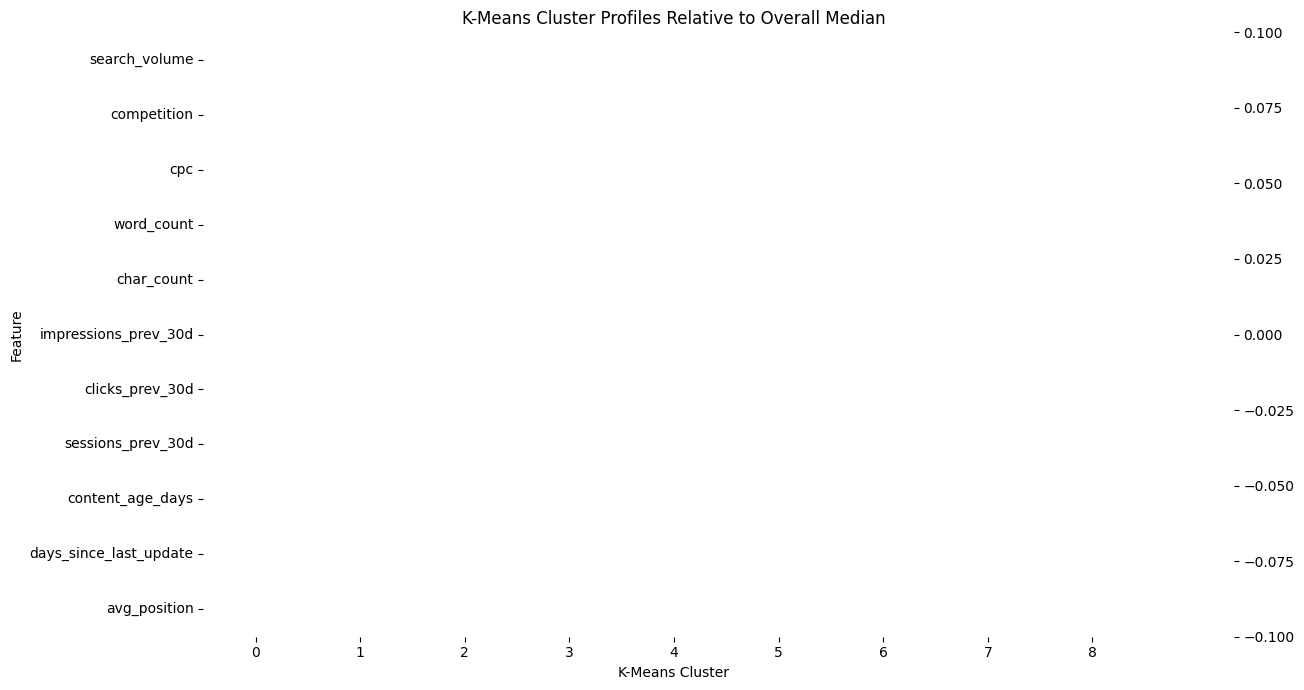

In [27]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    kmeans_ratio.T,
    annot=True,
    fmt=".2f",
    center=1,
    cmap="vlag"
)

plt.title("K-Means Cluster Profiles Relative to Overall Median")
plt.xlabel("K-Means Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 26. Interpret Clusters Using Existing Outcome Signals

The clusters were created **without** using the decline label.

Now we can bring the outcome variables back in to understand what each discovered segment represents.

If available, we inspect:

- decline rate
- trend direction
- average impressions
- average clicks
- average sessions

This is an interpretation step, not part of the clustering algorithm.


In [28]:
# 27. Outcome-based cluster interpretation

interpretation_cols = [
    col for col in [
        "impressions_last_30d",
        "trend_direction",
        "is_declining_label"
    ]
    if col in df_seg.columns
]

if interpretation_cols:
    if "is_declining_label" in interpretation_cols:
        outcome_profile = (
            df_seg
            .groupby("kmeans_cluster")
            .agg(
                article_count=("kmeans_cluster", "size"),
                decline_rate=("is_declining_label", "mean")
            )
        )

        if "impressions_last_30d" in interpretation_cols:
            outcome_profile["median_impressions_last_30d"] = (
                df_seg.groupby("kmeans_cluster")["impressions_last_30d"]
                .median()
            )

        display(outcome_profile)
    else:
        display(
            df_seg.groupby("kmeans_cluster")[interpretation_cols]
            .agg(lambda x: x.value_counts().index[0])
        )
else:
    print("No supported outcome columns were found for cluster interpretation.")


,impressions_last_30d,trend_direction
kmeans_cluster,,
0,0,down
1,0,up
2,534,down
3,0,down
4,0,down
5,0,down
6,0,down
7,1,down
8,0,down


trend_direction,down,flat,new,stable,up
kmeans_cluster,,,,,
0,66.7,0.1,0.0,24.4,8.9
1,33.9,3.3,8.0,17.7,37.2
2,52.6,0.0,0.0,34.2,13.1
3,59.8,4.9,12.1,11.6,11.6
4,62.2,2.9,0.6,21.4,13.0
5,47.9,2.4,1.6,30.2,17.9
6,57.2,4.5,5.8,16.6,15.9
7,42.9,11.1,27.0,8.9,10.0
8,57.9,3.7,3.7,17.4,17.3


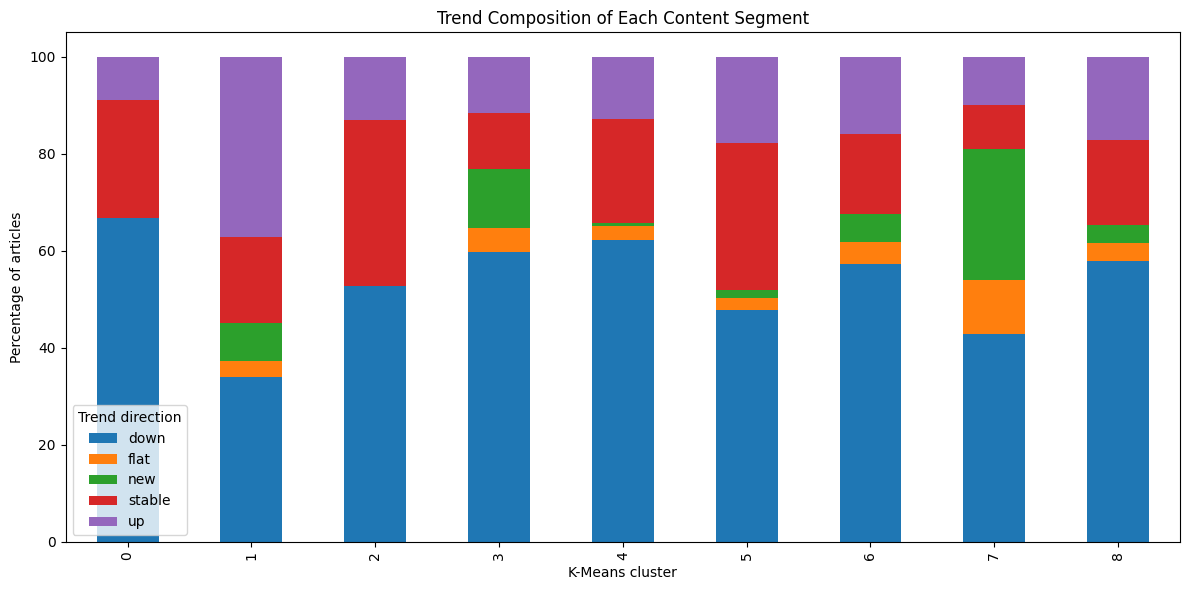

In [29]:
# 28. Trend distribution inside each K-Means cluster

if "trend_direction" in df_seg.columns:
    trend_by_cluster = pd.crosstab(
        df_seg["kmeans_cluster"],
        df_seg["trend_direction"],
        normalize="index"
    ) * 100

    display(trend_by_cluster.round(1))

    trend_by_cluster.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6)
    )

    plt.ylabel("Percentage of articles")
    plt.xlabel("K-Means cluster")
    plt.title("Trend Composition of Each Content Segment")
    plt.legend(title="Trend direction")
    plt.tight_layout()
    plt.show()


# 29. Automatic Segment Naming

Cluster IDs are arbitrary.

For example:

```text
Cluster 0
```

does **not** inherently mean "high traffic".

We therefore create a simple rule-based description from the cluster's median profile.

These names are **interpretations**, not labels learned by K-Means.


In [30]:
# 30. Generate interpretable segment descriptions

def describe_cluster(profile, overall):
    descriptions = []

    if profile["impressions_prev_30d"] > overall["impressions_prev_30d"] * 1.5:
        traffic = "High traffic"
    elif profile["impressions_prev_30d"] < overall["impressions_prev_30d"] * 0.67:
        traffic = "Low traffic"
    else:
        traffic = "Mid traffic"

    if profile["clicks_prev_30d"] > overall["clicks_prev_30d"] * 1.5:
        engagement = "high clicks"
    elif profile["clicks_prev_30d"] < overall["clicks_prev_30d"] * 0.67:
        engagement = "low clicks"
    else:
        engagement = "mid clicks"

    if profile["avg_position"] < overall["avg_position"] * 0.8:
        ranking = "strong ranking"
    elif profile["avg_position"] > overall["avg_position"] * 1.2:
        ranking = "weak ranking"
    else:
        ranking = "mid ranking"

    if profile["days_since_last_update"] > overall["days_since_last_update"] * 1.5:
        freshness = "stale content"
    elif profile["days_since_last_update"] < overall["days_since_last_update"] * 0.67:
        freshness = "recently updated"
    else:
        freshness = "moderate freshness"

    return f"{traffic} / {engagement} / {ranking} / {freshness}"


cluster_names = {}

for cluster_id, profile in kmeans_profile.drop(
    columns=["article_count", "share_pct"]
).iterrows():
    cluster_names[cluster_id] = describe_cluster(
        profile,
        overall_median
    )

cluster_name_table = pd.DataFrame({
    "kmeans_cluster": list(cluster_names.keys()),
    "segment_description": list(cluster_names.values())
})

display(cluster_name_table)


,kmeans_cluster,segment_description
0,0,High traffic / high clicks / weak ranking / st...
1,1,Low traffic / mid clicks / weak ranking / mode...
2,2,High traffic / high clicks / strong ranking / ...
3,3,Low traffic / mid clicks / mid ranking / moder...
4,4,Mid traffic / mid clicks / mid ranking / stale...
5,5,High traffic / mid clicks / mid ranking / mode...
6,6,Low traffic / mid clicks / mid ranking / moder...
7,7,Low traffic / mid clicks / strong ranking / mo...
8,8,Mid traffic / mid clicks / weak ranking / mode...


In [31]:
# 31. Add interpretable segment names

df_seg["segment_description"] = (
    df_seg["kmeans_cluster"].map(cluster_names)
)

display(
    df_seg[
        [
            "kmeans_cluster",
            "segment_description"
        ]
    ].head(20)
)


,kmeans_cluster,segment_description
0,6,Low traffic / mid clicks / mid ranking / moder...
1,5,High traffic / mid clicks / mid ranking / mode...
2,3,Low traffic / mid clicks / mid ranking / moder...
3,2,High traffic / high clicks / strong ranking / ...
4,5,High traffic / mid clicks / mid ranking / mode...
5,6,Low traffic / mid clicks / mid ranking / moder...
6,3,Low traffic / mid clicks / mid ranking / moder...
7,5,High traffic / mid clicks / mid ranking / mode...
8,2,High traffic / high clicks / strong ranking / ...
9,4,Mid traffic / mid clicks / mid ranking / stale...


# 32. Compare the Three Clustering Algorithms

K-Means, hierarchical clustering, and DBSCAN answer slightly different questions.

We compare:

- number of clusters
- noise/outlier percentage
- silhouette score
- cluster size balance

The goal is not necessarily to pick one universal winner. The algorithms can reveal different structures in the content population.


In [32]:
# 33. Compare clustering quality

comparison = []

for name, labels in [
    ("K-Means", kmeans_labels),
    ("Hierarchical", hierarchical_labels),
]:
    comparison.append({
        "algorithm": name,
        "clusters": len(np.unique(labels)),
        "noise_pct": 0.0,
        "silhouette": silhouette_score(X_cluster_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster_scaled, labels),
    })

db_non_noise = dbscan_labels != -1
db_clusters = len(set(dbscan_labels[db_non_noise]))

if db_clusters >= 2:
    db_silhouette = silhouette_score(
        X_cluster_scaled.loc[db_non_noise],
        dbscan_labels[db_non_noise]
    )
    db_db = davies_bouldin_score(
        X_cluster_scaled.loc[db_non_noise],
        dbscan_labels[db_non_noise]
    )
else:
    db_silhouette = np.nan
    db_db = np.nan

comparison.append({
    "algorithm": "DBSCAN",
    "clusters": db_clusters,
    "noise_pct": (~db_non_noise).mean() * 100,
    "silhouette": db_silhouette,
    "davies_bouldin": db_db,
})

comparison = pd.DataFrame(comparison)

display(comparison)


,algorithm,clusters,noise_pct,silhouette,davies_bouldin
0,K-Means,9,0.000000,0.223890,1.488174
1,Hierarchical,9,0.000000,0.185759,1.637635
2,DBSCAN,2,1.483333,0.290697,0.813502


# 34. Identify Potential FlyRank Segments

We can now inspect the discovered clusters as business segments.

Typical interpretations may include:

### High traffic / declining
Potentially valuable pages whose traffic base is at risk.

### High traffic / growing
Strong performers that may deserve protection and continued investment.

### Low traffic / declining
Candidates for consolidation, refresh, or lower priority.

### Low traffic / stable
Potential long-tail content that may require a different strategy.

### High engagement / weak ranking
Potential SEO opportunities where users respond well once they arrive, but visibility is weak.

### Stale content
Older pages with long periods since update that may be candidates for content refresh.

The actual segments must be determined from the notebook's measured cluster profiles rather than assumed beforehand.


In [33]:
# 35. Export article-level segmentation results

export_columns = [
    col for col in [
        "kmeans_cluster",
        "hierarchical_cluster",
        "dbscan_cluster",
        "segment_description"
    ]
    if col in df_seg.columns
]

segmentation_output = df_seg[
    export_columns + SEGMENTATION_FEATURES
].copy()

if "trend_direction" in df_seg.columns:
    segmentation_output["trend_direction"] = df_seg["trend_direction"]

if "is_declining_label" in df_seg.columns:
    segmentation_output["is_declining_label"] = df_seg["is_declining_label"]

if "impressions_last_30d" in df_seg.columns:
    segmentation_output["impressions_last_30d"] = df_seg["impressions_last_30d"]

segmentation_output.to_csv(
    OUTPUT_DIR / "content_segmentation_results.csv",
    index=False
)

kmeans_profile.to_csv(
    OUTPUT_DIR / "kmeans_cluster_profiles.csv"
)

comparison.to_csv(
    OUTPUT_DIR / "clustering_algorithm_comparison.csv",
    index=False
)

print("Saved segmentation outputs to:", OUTPUT_DIR)


Saved segmentation outputs to: outputs_content_segmentation


# 36. Save the Clustering Model Components

The imputer, scaler, K-Means model, and feature definitions are saved so that the segmentation process can later be reused on new content.

For production deployment, the preprocessing and clustering model should eventually be versioned together.


In [34]:
# 37. Save reusable segmentation artifacts

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "segmentation_features": SEGMENTATION_FEATURES,
        "log_features": LOG_FEATURES,
        "kmeans": kmeans,
        "cluster_names": cluster_names,
    },
    OUTPUT_DIR / "content_segmentation_kmeans_artifacts.joblib"
)

print("Saved model artifacts.")


Saved model artifacts.


# 38. Final Interpretation Checklist

Before presenting the segmentation to stakeholders, answer:

1. **How many meaningful content segments did we discover?**
2. **How large is each segment?**
3. **What makes each segment different from the overall content population?**
4. **Which segments have the highest decline rate?**
5. **Which segments contain the highest-value traffic?**
6. **Which segments have weak ranking but strong engagement?**
7. **Which segments appear stale and may need refreshing?**
8. **Do K-Means, hierarchical clustering, and DBSCAN tell a consistent story?**
9. **Are the clusters stable if preprocessing or the random seed changes?**
10. **Can each segment be connected to a concrete FlyRank action?**

The ultimate goal is not simply to produce cluster numbers.

The goal is to turn those clusters into **actionable content strategies**.


# 39. Project Position

This notebook implements **Opportunity 4 — Content Segmentation** as an unsupervised-learning problem.

The resulting FlyRank workflow becomes:

```text
Content data
     ↓
Feature engineering / preprocessing
     ↓
Unsupervised clustering
     ↓
Content segments
     ↓
Cluster profiling
     ↓
Business interpretation
     ↓
Segment-specific content strategy
```

Combined with the other FlyRank opportunities:

```text
Opportunity 1 → Predict content decline
Opportunity 2 → Predict future traffic
Opportunity 4 → Discover content segments
Opportunity 5 → Explain model predictions
```

This creates a much more complete Data Science system than a single predictive model.
